# GDL - Midterm n.1
**Student ID: 000000** 

**Submission ID: 052** 

In the first midterm assignment, you are required to implement a Gaussian Mixture Model (GMM) and the Expectation-Maximization (EM) algorithm. You are allowed to use `numpy` and other non-machine learning libraries, e.g., `pandas`, `matplotlib`.

**Assumptions.** To ease the implementation, we assume, for each Gaussian distribution in the mixture $\mathcal{N}(\mu_k, \Sigma_k)$, that the *covariance matrix is diagonal*. Furthermore, keep in mind that a good implementation of the EM algorithm provides monotonically increasing log-likelihood, *but* can get stuck in local minima; initialization strategies are fundamental (random? sample points? k-means++?).

**Hyperparameter $k$.** When using a GMM, you should ask yourself: *how many mixtures will be in the data?* You can *maximize* the Bayesian Information Criterion (BIC) to select the number of categories $k$ on your training set. Formally,
$$
\text{BIC}
=
\log P(X\mid \theta) - \frac{|\theta|}{2}\log n,
$$
where $n$ is the number of samples in the training set, $\theta=\{\pi,\mu,\sigma\}$ the parameters of the GMM and $|\theta|$ the number of parameters, i.e., the sum of the number of parameters in $\pi$, $\mu$, and $\sigma$ (*hint*: it also depends on the dimensionality of data $d$!).

**Summary.** Overall, you are required to:
1.  **Implement the GMM class**. Fill the `log_likelihood(samples)`.
2. **Implement the EM algorithm**. Fill the `fit(samples)` method to fit the parameters of a GMM.
3. **Implement the BIC score**. Fill the `bic(samples)` method to perform model selection.
4. **Run training and evaluation**. Select the best scoring model using BIC (Bayesian Information Criterion) for values of $k=\{1,\ldots,6\}$.

**Evaluation.** Your solution will be tested against an hidden test set. For your learning experience, we require you to refrain from using LLM generated code. Violations will be flagged and invalidate the midterm. **Do not alter Sections 3 and 4 of the notebook.**

### 1. Libraries

In [1]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)

print("Libraries imported successfully.")

Libraries imported successfully.


### 2. Gaussian Mixture Model (GMM)

Feel free to play around the implementation. **For evaluation purposes**, the class **must** expose the following attributes and methods:
- `_pi: np.ndarray`
- `_mu: np.ndarray`
- `_sigma: np.ndarray`
- `fit(samples: np.ndarray)`
- `bic(samples: np.ndarray) -> np.ndarray`
- `log_likelihood(samples: np.ndarray) -> np.ndarray`

In [ ]:
class GaussianMixtureModel:
    def __init__(self, n_categories: int, n_features: int, debug: bool = False, plot: bool = False):
        self.n_categories = n_categories #K (= quantità di gaussiane nel GMM)
        self.n_features = n_features # d

        # weights (pi), means (mu), covariances (sigma)
        # NOTE: for the covariance, you can store only the diagonal
        self._pi = None # Shape: (n_categories,)
        self._mu = None   # Shape: (n_categories, n_features)
        self._sigma = None # Shape: (n_categories, n_features)

        #pi, mu, sigma initialized in fit using K-mean++
        self.max_iteration = 1000
        self.epsilon = 1e-8

        # flags
        self.debug = debug
        self.plot = plot
        self._ll_history = [] #for charts 

    def _compute_matrix_log_weighted(self, samples: np.ndarray): 
        """
        compute matrix (N,K) 
        with element [j, k] = log(pi_k) + log N(x_j | mu_k, sigma_k)
        -> the probability that a sample j is under the component k (in log-space)
        
        for each sample j it compute:
        log w ik = log pi k + log N(xj|uk, sigma k)
        """
        d = self.n_features
        assert samples.shape[1] == d, f"d ({d}) != samples.shape[1] ({samples.shape[1]})"

        #(x_l - mu_k_l)
        diff = samples[:, None, :] - self._mu[None, :, :]

        #(x_{j,l} - mu_{k,l})^2
        diff_sq = diff ** 2 

        #(x_{j,l} - mu_{k,l})^2 / sigma_{k,l}^2
        scaled = diff_sq / self._sigma[None, :, :] 

        #Sum over d feature (last axis) -> somma_l (=> l = 1...d)
        third_term = np.sum(scaled, axis=2) 

        #Sum (l=1...d) of the logs of the variances: sum_l log(sigma_{k,l}^2)
        second_term_log_var_sum = np.sum(np.log(self._sigma), axis=1) 

        #log N(x_j | mu_k, sigma_k) = -d/2*log(2pi) - 1/2*second_term_log_var_sum - 1/2*third_term
        log_gauss = -0.5 * d * np.log(2 * np.pi) - 0.5 * second_term_log_var_sum[None, :] - 0.5 * third_term 
        
        #add log(pi_k) (<-- log(a*b) = log(a) + log(b) )
        log_weighted = log_gauss + np.log(self._pi)[None, :] 

        return log_weighted
        
    def log_likelihood(self, samples: np.ndarray) -> np.ndarray:
        """Computes logP(X|θ) -> incomplete log likelihood"""
        log_w = self._compute_matrix_log_weighted(samples)

        #avoid underflow: log(summation_k(e^a_k)) = a_max + log(summation_k(e^(a_k-a_max)))
        #where a_max = max for k of a_k
        a_max = np.max(log_w, axis=1) 
        log_sum = a_max + np.log(np.sum(np.exp(log_w - a_max[:, None]), axis=1)) 
        
        return np.sum(log_sum)

    
    def k_means_init(self, samples: np.ndarray):
        sample_quantity, features_quantity = samples.shape

        #init arr centroids (K, feature_quantity), K = self.n_categories
        centroids = np.empty((self.n_categories, features_quantity))

        #choose random 1th centroid
        centroids[0] = samples[(np.random.randint(sample_quantity))]

        #choose the other K-1 centroids
        for k in range(1, self.n_categories):
            
            #distances for each sample xj : ||x_j - mu_k_prime||^2
            dist_sq = np.array(
                [np.sum((samples-mu_k_prime)**2, axis=1) for mu_k_prime in centroids[:k]]
            )

            #D(x_j) = min distance for each sample:
            min_dist_sq = np.min(dist_sq, axis=0)

            # P(choose x_j) = D(x_j) / sum(D)
            probabilities = min_dist_sq / np.sum(min_dist_sq)

            #next index chosen using probability distribution:
            next_index = np.random.choice(sample_quantity, p=probabilities)
            
            centroids[k] = samples[next_index]

        return centroids

    
    def fit(self, samples: np.ndarray):
        """Fits the GMM parameters using the EM algorithm."""        

        #check and initialize 
        if self._mu is None:
            self._mu = self.k_means_init(samples)

        if self._pi is None:
            self._pi = np.full(self.n_categories, 1.0 / self.n_categories)
        
        if self._sigma is None:
            self._sigma = np.tile(np.var(samples, axis=0), (self.n_categories, 1))
    
        #EM:
        N = samples.shape[0] 
        prev_ll = -np.inf
        self._ll_history = []

        for t in range(self.max_iteration):
            
            #E-step => compute "responsability" matrix (shape (N,K) )
            log_w = self._compute_matrix_log_weighted(samples) #get log(pi_k)+log(N(x_j | mu_k, sigma_k)) = log(pi_k * (N(x_j | mu_k, sigma_k)) )
            
            #avoid underflow: log(summation_k(e^a_k)) = a_max + log(summation_k(e^(a_k-a_max)))
            #-> a_max = max for k of a_k
            a_max = np.max(log_w, axis=1) 
            log_denominator = a_max + np.log(np.sum(np.exp(log_w - a_max[:, None]), axis=1)) 
            
            #gamma = P(zj = k | xj, theta(t) ) -> responsabilities (posterior)
            #use log(a) - log(b) = log(a/b) and then exp(log(a/b)) to obtain a/b
            #where a/b = gamma = (pi_k*N(xj|mu_k, sigma_k)) / (summation over K of pi_k*N(xj|mu_k, sigma_k) )
            #where (pi_k*N(xj|mu_k, sigma_k)) = log_w
            gamma = np.exp(log_w - log_denominator[:, None])

            if self.debug:
                row_sums = gamma.sum(axis=1)
                assert np.allclose(row_sums, 1.0, atol=1e-6), f"Gamma rows don't sum to 1: min={row_sums.min():.6f}, max={row_sums.max():.6f}"

            #M-step
            N_k = gamma.sum(axis=0) #=> summation over N
            N_k = np.maximum(N_k, 1e-10) # floor to avoid division by zero when a component dies

            self._pi = N_k / N #-> update π
            self._mu = gamma.T @ samples / N_k[:, None] #-> update mu

            diff = samples[:, None, :] - self._mu[None, :, :]
            self._sigma = np.sum(gamma[:, :, None] * diff**2, axis=0) / N_k[:, None] #-> update sigma 
            self._sigma = np.maximum(self._sigma, 1e-6) 

            if self.debug:
                assert np.allclose(self._pi.sum(), 1.0, atol=1e-6), f"Pi doesn't sum to 1: {self._pi.sum()}"
                assert np.all(self._sigma > 0), "Negative/zero variances found"

            ll = np.sum(log_denominator)
            self._ll_history.append(ll)

            if self.debug:
                if ll < prev_ll - 1e-6:
                    print(f"(!) WARNING iter {t}: ll decreased {prev_ll:.4f} -> {ll:.4f}")
                if t % 20 == 0:
                    print(f"  iter {t:4d}: ll={ll:.4f}")

            if np.abs(ll - prev_ll) < self.epsilon:
                if self.debug:
                    print(f"EM converged in {t+1} iterations, final ll={ll:.4f}")
                break

            prev_ll = ll

        if self.plot:
            self._plot_convergence()

    def _plot_convergence(self):
        """convergence of LL during EM"""
        plt.figure(figsize=(8, 4))
        plt.plot(self._ll_history, marker=".", markersize=3)
        plt.xlabel("Iteration")
        plt.ylabel("Log likelihood")
        plt.title(f"Convergence EM (K={self.n_categories})")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def bic(self, samples: np.ndarray) -> np.ndarray:
        """Computes the BIC score."""
        ll = self.log_likelihood(samples)
        n = samples.shape[0]
        d = samples.shape[1]
        n_params = (self.n_categories - 1) + 2 * self.n_categories * d
        return ll - (n_params / 2) * np.log(n)


### 2.1 Debug & Test

  iter    0: ll=-9132.8980
  iter   20: ll=-7812.4306
EM converged in 31 iterations, final ll=-7812.4306


/var/folders/7g/q0yqpn0s3fx0_yp3mt53zdyc0000gn/T/ipykernel_20558/2543716370.py:142: RuntimeWarning: divide by zero encountered in matmul
  self._mu = gamma.T @ samples / N_k[:, None] #-> update mu
/var/folders/7g/q0yqpn0s3fx0_yp3mt53zdyc0000gn/T/ipykernel_20558/2543716370.py:142: RuntimeWarning: overflow encountered in matmul
  self._mu = gamma.T @ samples / N_k[:, None] #-> update mu
/var/folders/7g/q0yqpn0s3fx0_yp3mt53zdyc0000gn/T/ipykernel_20558/2543716370.py:142: RuntimeWarning: invalid value encountered in matmul
  self._mu = gamma.T @ samples / N_k[:, None] #-> update mu


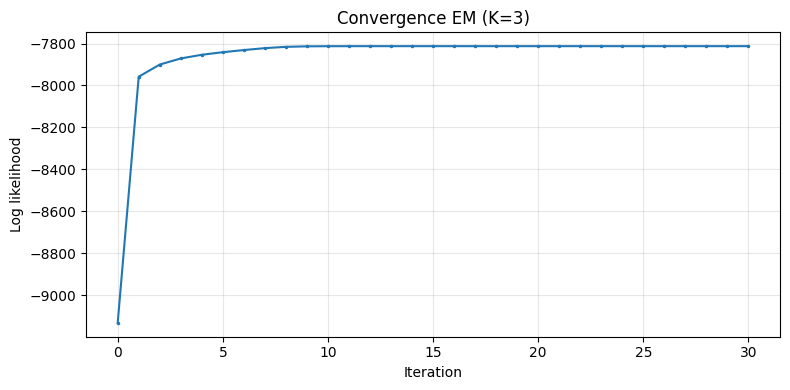


Final ll: -7812.4306
BIC: -7919.3844
pi: [0.4186385  0.46030276 0.12105874]
mu:
[[-2.00250091  0.59750876 -2.38651942 -0.57318638 -0.17917197]
 [-2.80122377 -0.87866414 -0.1470691   2.12913745 -2.64879876]
 [ 1.87807098  2.39297349 -0.1983124   0.26440534 -0.79074812]]


In [3]:
# load data for debug
train_df = pd.read_csv("train.csv")


seed_everything(9951)
for _k in range(1, 3): #K=1 e K=2 
    _gmm = GaussianMixtureModel(n_categories=_k, n_features=train_df.shape[1])
    _gmm.fit(train_df.values)

#K=3:
gmm = GaussianMixtureModel(n_categories=3, n_features=train_df.shape[1], debug=True, plot=True)
gmm.fit(train_df.values)
print(f"\nFinal ll: {gmm.log_likelihood(train_df.values):.4f}")
print(f"BIC: {gmm.bic(train_df.values):.4f}")
print(f"pi: {gmm._pi}")
print(f"mu:\n{gmm._mu}")


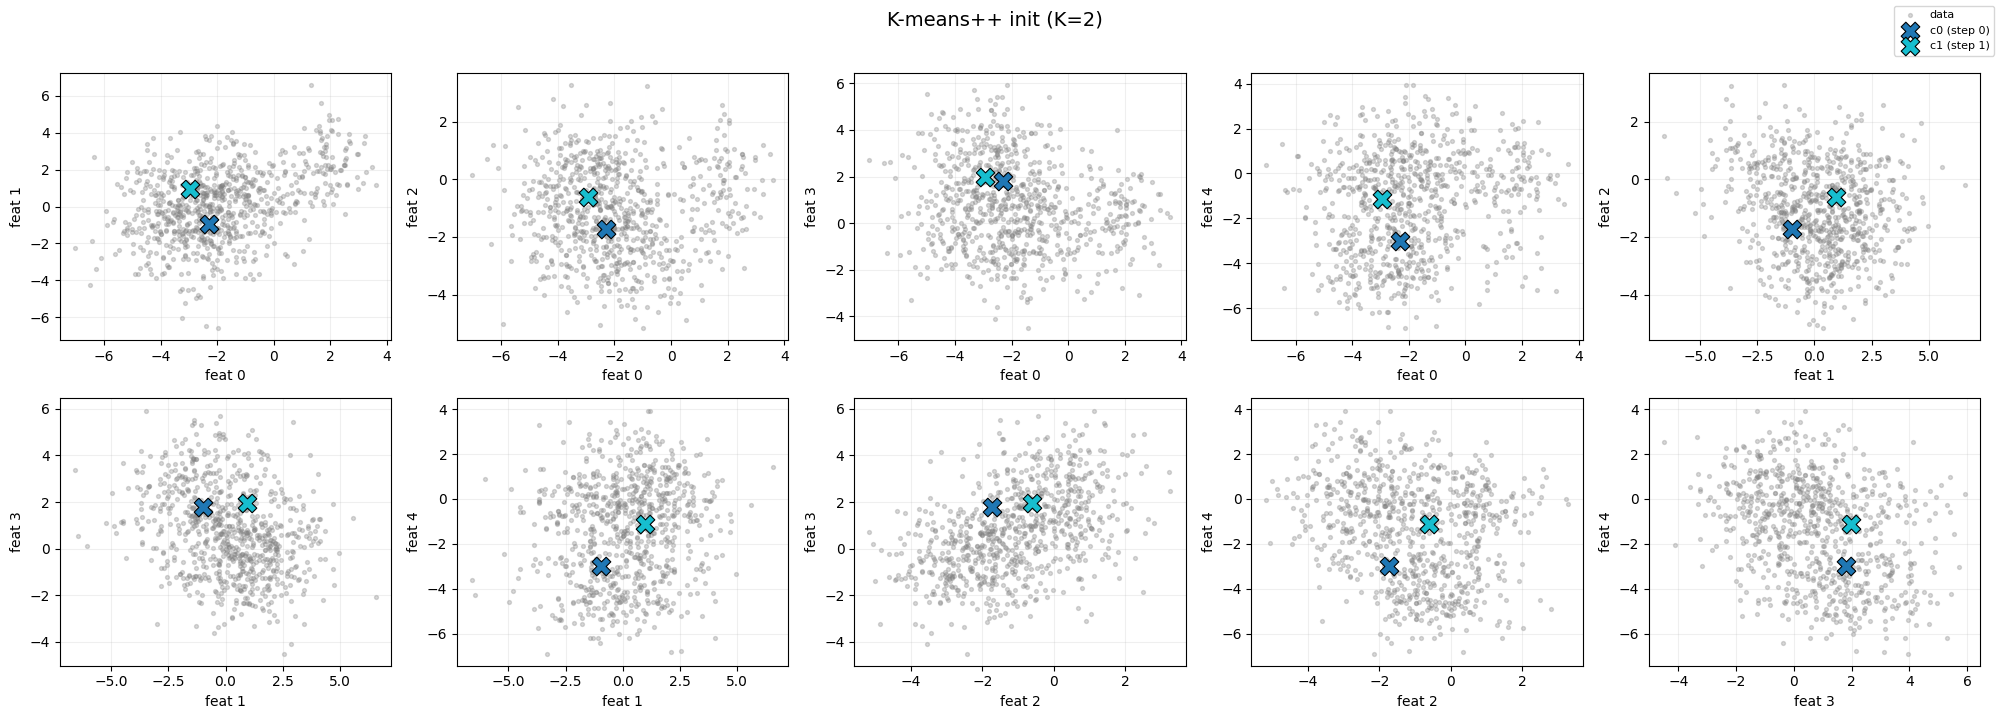

/var/folders/7g/q0yqpn0s3fx0_yp3mt53zdyc0000gn/T/ipykernel_20558/2543716370.py:142: RuntimeWarning: divide by zero encountered in matmul
  self._mu = gamma.T @ samples / N_k[:, None] #-> update mu
/var/folders/7g/q0yqpn0s3fx0_yp3mt53zdyc0000gn/T/ipykernel_20558/2543716370.py:142: RuntimeWarning: overflow encountered in matmul
  self._mu = gamma.T @ samples / N_k[:, None] #-> update mu
/var/folders/7g/q0yqpn0s3fx0_yp3mt53zdyc0000gn/T/ipykernel_20558/2543716370.py:142: RuntimeWarning: invalid value encountered in matmul
  self._mu = gamma.T @ samples / N_k[:, None] #-> update mu


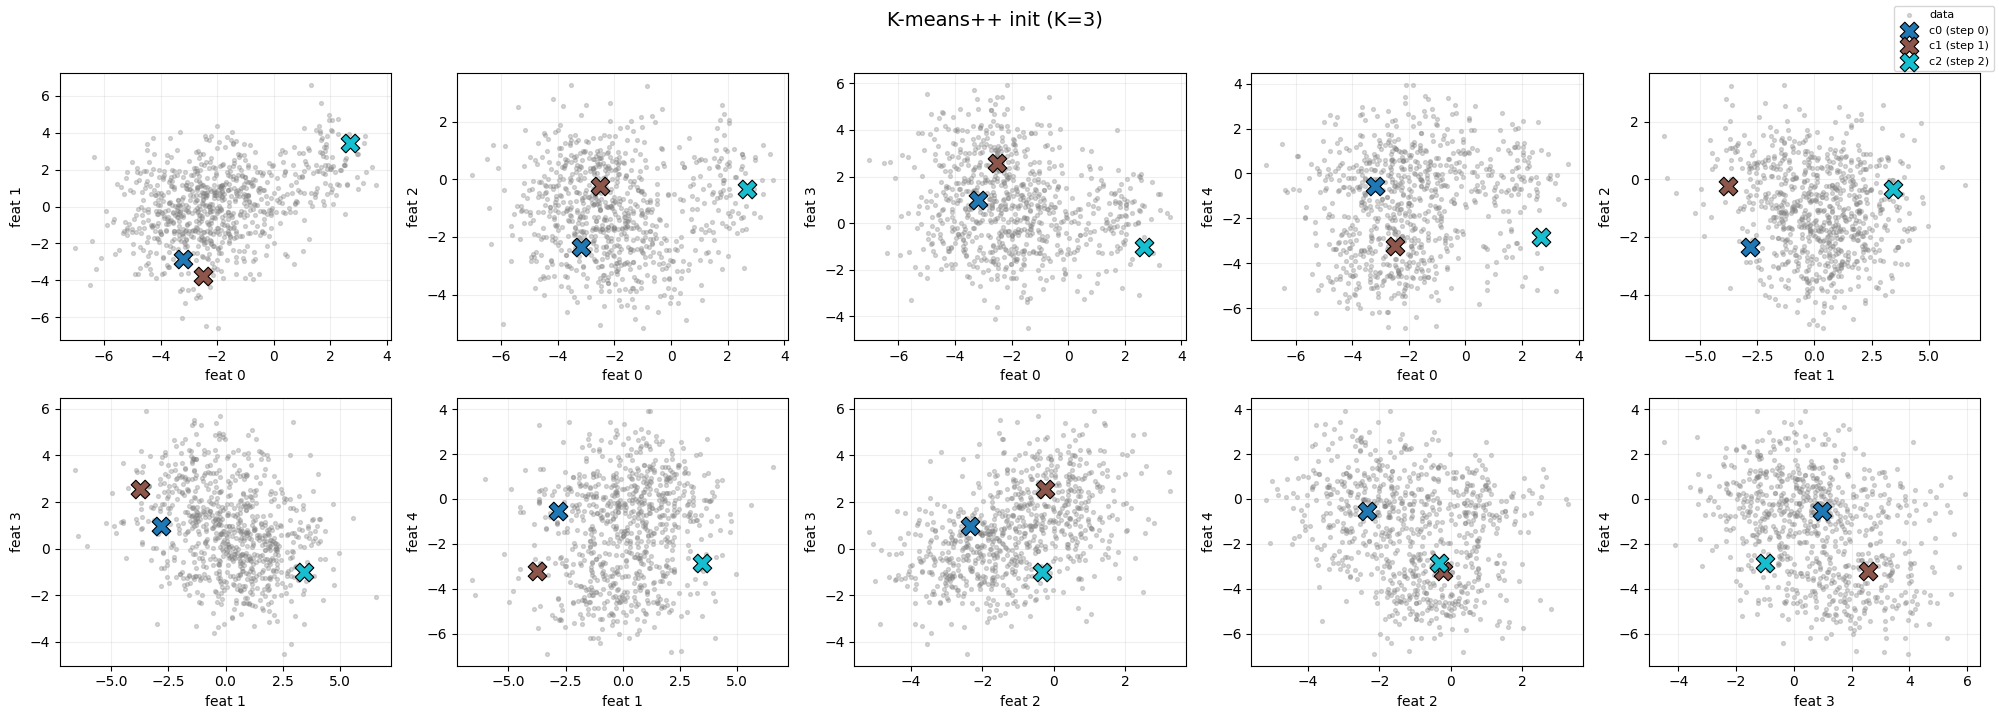

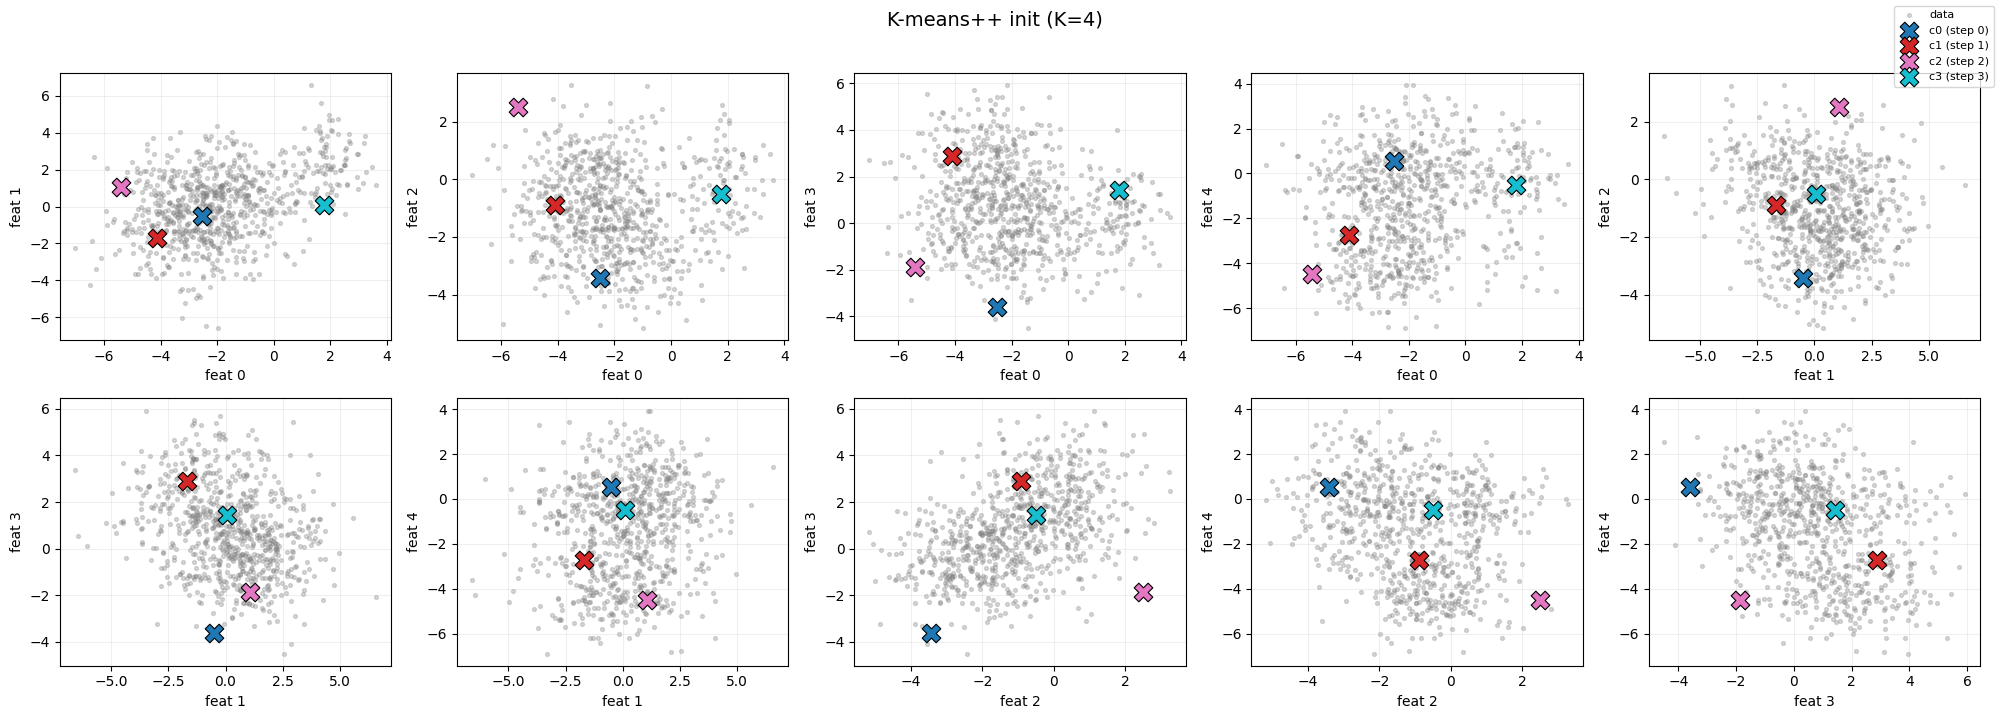

In [4]:
from itertools import combinations

samples = train_df.values
n_features = samples.shape[1]
feature_pairs = list(combinations(range(n_features), 2))

for K in range(2, 5):    
    seed_everything(9951)
    for _k in range(1, K):
        _gmm = GaussianMixtureModel(n_categories=_k, n_features=n_features)
        _gmm.fit(samples)
    
    centroids_history = []
    centroids = np.empty((K, n_features))
    centroids[0] = samples[np.random.randint(samples.shape[0])]
    centroids_history.append(centroids[0].copy())

    for k in range(1, K):
        dist_sq = np.array(
            [np.sum((samples - mu_k_prime) ** 2, axis=1) for mu_k_prime in centroids[:k]]
        )
        min_dist_sq = np.min(dist_sq, axis=0)
        probabilities = min_dist_sq / np.sum(min_dist_sq)
        centroids[k] = samples[np.random.choice(samples.shape[0], p=probabilities)]
        centroids_history.append(centroids[k].copy())

    centroids_history = np.array(centroids_history)

    
    n_pairs = len(feature_pairs)
    cols = min(n_pairs, 5)
    rows = (n_pairs + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows))
    axes = np.atleast_1d(axes).flatten()
    fig.suptitle(f'K-means++ init (K={K})', fontsize=14, y=1.02)

    for idx, (fi, fj) in enumerate(feature_pairs):
        ax = axes[idx]
        ax.scatter(samples[:, fi], samples[:, fj], s=8, alpha=0.3, c='grey', label='data')
        colors = plt.cm.tab10(np.linspace(0, 1, K))
        for step, (cx, cy) in enumerate(zip(centroids_history[:, fi], centroids_history[:, fj])):
            ax.scatter(cx, cy, s=180, marker='X', color=colors[step],
                       edgecolors='black', linewidths=0.8, zorder=5,
                       label=f'c{step} (step {step})')
        ax.set_xlabel(f'feat {fi}')
        ax.set_ylabel(f'feat {fj}')
        ax.grid(True, alpha=0.2)

    for idx in range(len(feature_pairs), len(axes)):
        axes[idx].set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()


### 3. Training

Trains the model for increasing number of categories and selects the best scoring one in terms of BIC score.

In [5]:
# load training set
train_df = pd.read_csv("train.csv")
print(f"train.csv loaded successfully. n={train_df.shape[0]}, d={train_df.shape[1]}")

# model selection using bayesian information score
seed_everything(9951)
candidate_categories = range(1, 7)
max_bic, best_k, best_gmm = -np.inf, None, None
for k in candidate_categories:
    gmm = GaussianMixtureModel(n_categories=k, n_features=train_df.shape[1])
    gmm.fit(train_df.values)
    ll = gmm.log_likelihood(train_df.values)
    bic_score = gmm.bic(train_df.values)
    print(f"k={k}\tBIC={bic_score:.4f}\tlogP(X|θ)={ll:.4f}")
    if bic_score > max_bic:
        max_bic = bic_score
        best_k = k
        best_gmm = gmm

# print training info
print()
print("Best model")
print(f"k:\t\t{best_k}")
print(f"BIC:\t\t{max_bic:.4f}")
print(f"logP(X|θ):\t{best_gmm.log_likelihood(train_df.values):.4f}")

train.csv loaded successfully. n=800, d=5
k=1	BIC=-8320.1771	logP(X|θ)=-8286.7541
k=2	BIC=-8052.0416	logP(X|θ)=-7981.8532
k=3	BIC=-7919.3844	logP(X|θ)=-7812.4306
k=4	BIC=-7869.8688	logP(X|θ)=-7726.1496
k=5	BIC=-7899.1658	logP(X|θ)=-7718.6813
k=6	BIC=-7916.2819	logP(X|θ)=-7699.0320

Best model
k:		4
BIC:		-7869.8688
logP(X|θ):	-7726.1496


/var/folders/7g/q0yqpn0s3fx0_yp3mt53zdyc0000gn/T/ipykernel_20558/2543716370.py:142: RuntimeWarning: divide by zero encountered in matmul
  self._mu = gamma.T @ samples / N_k[:, None] #-> update mu
/var/folders/7g/q0yqpn0s3fx0_yp3mt53zdyc0000gn/T/ipykernel_20558/2543716370.py:142: RuntimeWarning: overflow encountered in matmul
  self._mu = gamma.T @ samples / N_k[:, None] #-> update mu
/var/folders/7g/q0yqpn0s3fx0_yp3mt53zdyc0000gn/T/ipykernel_20558/2543716370.py:142: RuntimeWarning: invalid value encountered in matmul
  self._mu = gamma.T @ samples / N_k[:, None] #-> update mu


### 4. Evaluation

To check if you did not break the API, you can use the training file to run the tests.

This is not meaningful for the evaluation of your model, as the true test set is hidden.

In [6]:
# If test.csv does not exist copy train into test
!test -f test.csv || cp train.csv test.csv

In [7]:
# load hidden test set ☠️
test_df = pd.read_csv('test.csv')
print(f"test.csv loaded successfully. n={test_df.shape[0]}, d={test_df.shape[1]}")

# print log-likelihood
test_log_likelihood = best_gmm.log_likelihood(test_df.values)
print(f"Log-likelihood of test data: {test_log_likelihood:.4f}")

# print parameters
print(f"k: {best_gmm.n_categories}")
print()
for cat_id in range(best_gmm.n_categories):
  print(f"π[{cat_id}]:", best_gmm._pi[cat_id])
  print(f"μ[{cat_id}]:", best_gmm._mu[cat_id])
  print(f"σ[{cat_id}]:", best_gmm._sigma[cat_id])
  print()

test.csv loaded successfully. n=800, d=5
Log-likelihood of test data: -7726.1496
k: 4

π[0]: 0.43517279492603383
μ[0]: [-2.01548797  0.56096406 -2.33860348 -0.50669979 -0.1094654 ]
σ[0]: [2.56342387 2.24906925 1.23122302 1.64868502 2.78841542]

π[1]: 0.12069549272197598
μ[1]: [-2.94846673 -1.75756122  0.81523395  2.46365647 -0.09922658]
σ[1]: [2.33141689 2.57932523 0.76284594 2.37036512 0.66120667]

π[2]: 0.3234311973858058
μ[2]: [-2.76489237 -0.57491785 -0.45669783  2.05087861 -3.81425885]
σ[2]: [1.56477734 3.15750758 1.05202266 2.20581063 1.56049262]

π[3]: 0.12070051496618434
μ[3]: [ 1.87925077  2.39716282 -0.19702309  0.26454029 -0.80133678]
σ[3]: [0.49252241 1.76529577 1.39096934 1.55281467 3.24693064]



### 5. Conclusions

As can be seen from the BIC, the best model is the one with **k=4** components.

For each EM iteration, the log likelihood increases monotonically, confirming the algorithm's theoretical properties.

When k > 4, the additional components degenerate with minimum variance and almost zero weight, which seems to indicate that the data actually contains 4 clusters.

The BIC graph supports the previous statement, as the score improves up to k=4, then degrades and decreases for k=5 and k=6. This is because the penalty associated with the parameters is greater than the gain in likelihood.

/var/folders/7g/q0yqpn0s3fx0_yp3mt53zdyc0000gn/T/ipykernel_20558/2543716370.py:142: RuntimeWarning: divide by zero encountered in matmul
  self._mu = gamma.T @ samples / N_k[:, None] #-> update mu
/var/folders/7g/q0yqpn0s3fx0_yp3mt53zdyc0000gn/T/ipykernel_20558/2543716370.py:142: RuntimeWarning: overflow encountered in matmul
  self._mu = gamma.T @ samples / N_k[:, None] #-> update mu
/var/folders/7g/q0yqpn0s3fx0_yp3mt53zdyc0000gn/T/ipykernel_20558/2543716370.py:142: RuntimeWarning: invalid value encountered in matmul
  self._mu = gamma.T @ samples / N_k[:, None] #-> update mu


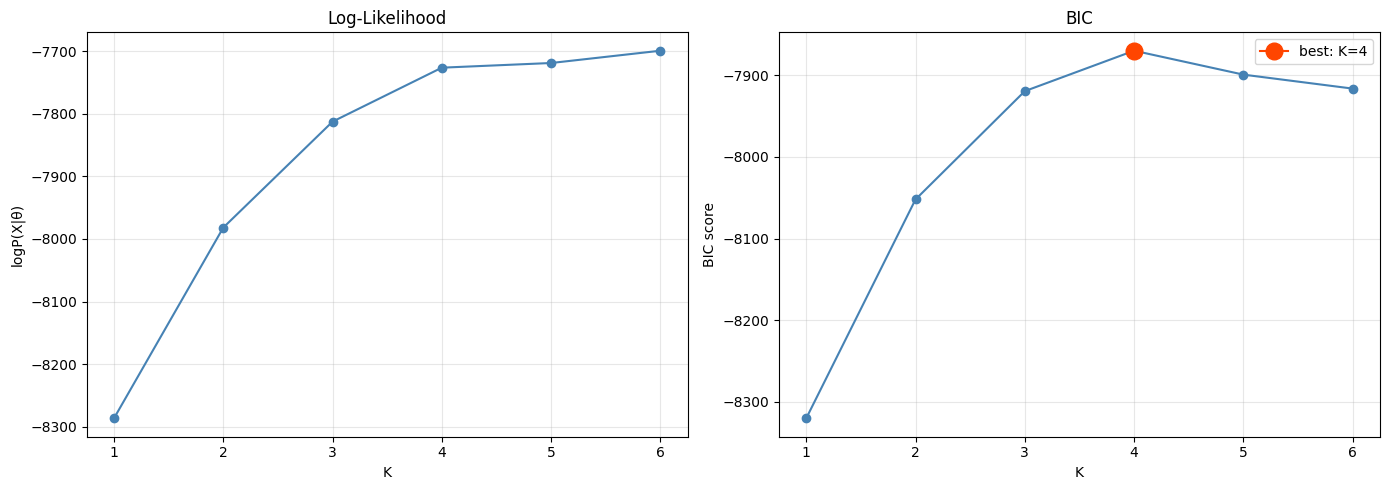

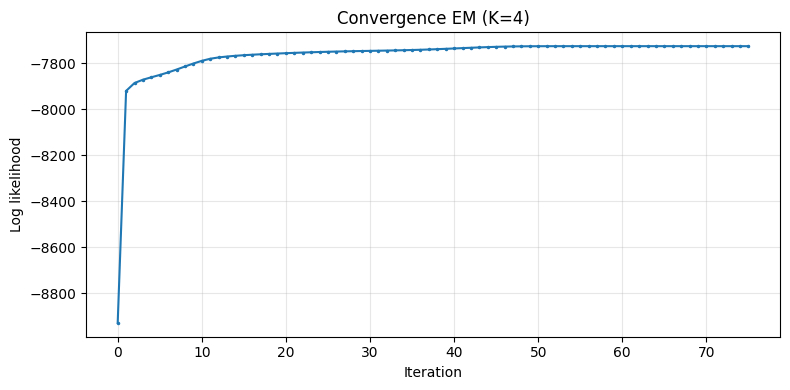

In [8]:
#model comparison:
seed_everything(9951)
bic_scores = []
ll_scores = []
for k in candidate_categories:
    gmm = GaussianMixtureModel(n_categories=k, n_features=train_df.shape[1])
    gmm.fit(train_df.values)
    bic_scores.append(gmm.bic(train_df.values))
    ll_scores.append(gmm.log_likelihood(train_df.values))

#plots for LL and BIC:
fig, (ax_ll, ax_bic) = plt.subplots(1, 2, figsize=(14, 5))

ax_ll.plot(list(candidate_categories), ll_scores, marker='o', color='steelblue')
ax_ll.set_title("Log-Likelihood")
ax_ll.set_xlabel("K")
ax_ll.set_ylabel("logP(X|θ)")
ax_ll.grid(True, alpha=0.3)

ax_bic.plot(list(candidate_categories), bic_scores, marker='o', color='steelblue')
best_idx = np.argmax(bic_scores)
ax_bic.plot(list(candidate_categories)[best_idx], bic_scores[best_idx],
            marker='o', markersize=12, color='orangered', zorder=5, label=f'best: K={best_idx+1}')
ax_bic.set_title("BIC")
ax_bic.set_xlabel("K")
ax_bic.set_ylabel("BIC score")
ax_bic.legend()
ax_bic.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_gmm._plot_convergence()
